### EDA ON FNSPID (Financial News and Stock Price Integration Dataset)

#### Importing Important Modules

In [2]:
#### Data Look Up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

#### 1.Descriptive Statistics: 

##### 1.1 Data Loading

In [ ]:
df = pd.read_csv(r"..\data\raw\raw_analyst_ratings.csv")
df. head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


##### 1.2 Keeping only required Columns

In [9]:
REQUIRED_COLUMNS = ["headline", "url", "publisher", "date", "stock"]
df = df[REQUIRED_COLUMNS]
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   headline   1407328 non-null  object
 1   url        1407328 non-null  object
 2   publisher  1407328 non-null  object
 3   date       1407328 non-null  object
 4   stock      1407328 non-null  object
dtypes: object(5)
memory usage: 53.7+ MB


##### 1.3 Headline Analysis(Discriptive)

In [10]:
headline_lengths = df['headline'].astype(str).apply(len)

In [14]:
length_stats = {
    'min': headline_lengths.min(),
    'max': headline_lengths.max(),
    'mean': headline_lengths.mean(),
    'median': headline_lengths.median(),
    'std': headline_lengths.std()
}
print("Headline Length Statistics:")
for stat, value in length_stats.items():
    print(f"{stat.capitalize()}: {value}")

Headline Length Statistics:
Min: 3
Max: 512
Mean: 73.12051490484095
Median: 64.0
Std: 40.73530993195064


#### 1.4 Visualizing Headline Length Distribution

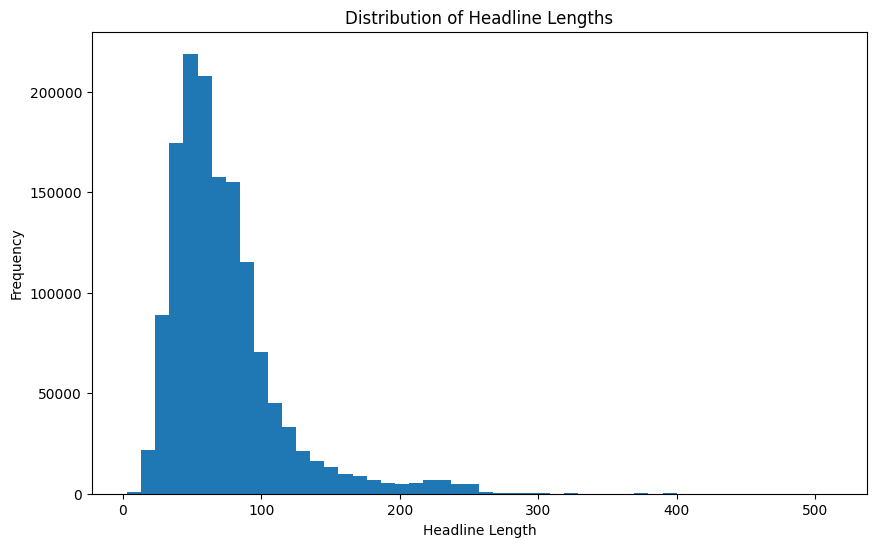

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(headline_lengths, bins=50)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length')
plt.ylabel('Frequency')
plt.show()

##### 1.5 Publisher Analysis

In [22]:
publisher_counts = (
    df["publisher"]
    .astype(str)          # defensive: handles missing values
    .str.strip()          # remove accidental whitespace
    .str.lower()          # normalize casing
    .value_counts()
    .reset_index()
)

publisher_counts.columns = ["publisher", "article_count"]

publisher_counts.head(10)

,publisher,article_count
0,paul quintaro,228373
1,lisa levin,186979
2,benzinga newsdesk,150484
3,charles gross,96732
4,monica gerson,82380
5,eddie staley,57254
6,hal lindon,49047
7,etf professor,28489
8,juan lopez,28438
9,benzinga staff,28114


##### 1.6 Publisher Distribution

<Axes: title={'center': 'Top 10 Most Active Publishers'}, xlabel='publisher'>

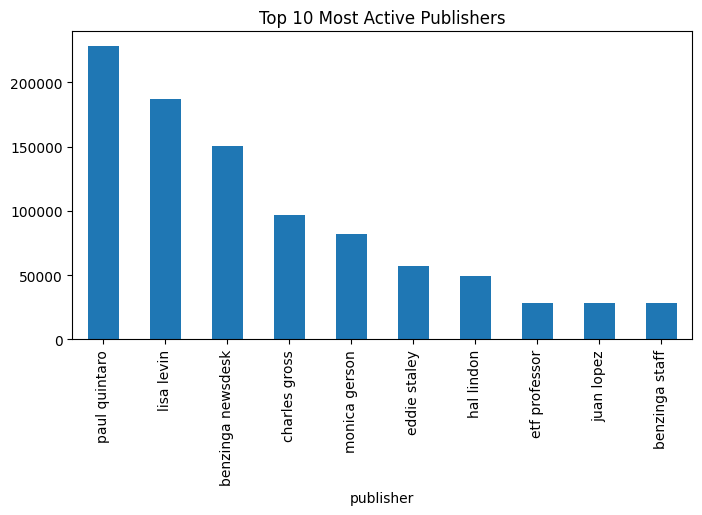

In [23]:
publisher_counts.head(10).plot(
    x="publisher",
    y="article_count",
    kind="bar",
    title="Top 10 Most Active Publishers",
    figsize=(8, 4),
    legend=False
)


#### 1.7 Analyze the publication dates to see trends over time

In [24]:
df.head()

,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [26]:
df.to_csv(r"..\data\clean\processed_analyst_ratings.csv", index=False)